In [11]:
import torch
from torch.utils.data import DataLoader, ConcatDataset
from torchvision import datasets, transforms
from torch import nn, optim
from transformers import ViTForImageClassification, ViTFeatureExtractor
from tqdm import tqdm

# 데이터셋 경로
train_dir = '/workspace/dataset/crop/train'
# val_dir = '/workspace/dataset/val_facenet512/image'
# test_dir = '/workspace/dataset/test_facenet512/image'

# 이미지 전처리 증강
transform_augment = transforms.Compose([
    transforms.RandomHorizontalFlip(),    # 랜덤 좌우 반전
    transforms.ColorJitter(               # 색상 변화
        brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1
    ),
    transforms.Resize((224, 224)),  # 모델 입력 크기에 맞게 이미지 리사이즈
    transforms.ToTensor(),  # 텐서로 변환
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),  # ResNet에 맞는 정규화
])

# 이미지 전처리 기본
transform_origin = transforms.Compose([
    transforms.Resize((224, 224)),  # 모델 입력 크기에 맞게 이미지 리사이즈
    transforms.ToTensor(),  # 텐서로 변환
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),  # ResNet에 맞는 정규화
])

# ImageFolder를 사용하여 train, val, test 세트 로드
train_dataset_origin = datasets.ImageFolder(root=train_dir, transform=transform_origin)
train_dataset_augment = datasets.ImageFolder(root=train_dir, transform=transform_augment)

# 두 데이터셋을 합치기
train_dataset = ConcatDataset([train_dataset_origin, train_dataset_augment])

# DataLoader 생성
train_dataloader_origin = DataLoader(train_dataset_origin, batch_size=50, shuffle=False)
train_dataloader_augment = DataLoader(train_dataset_augment, batch_size=50, shuffle=False)
train_dataloader = DataLoader(train_dataset, batch_size=50, shuffle=True)

In [4]:
# 클래스 이름 확인
print("Class labels:", train_dataset_origin.classes)


Class labels: ['anger', 'happy', 'panic', 'sadness']


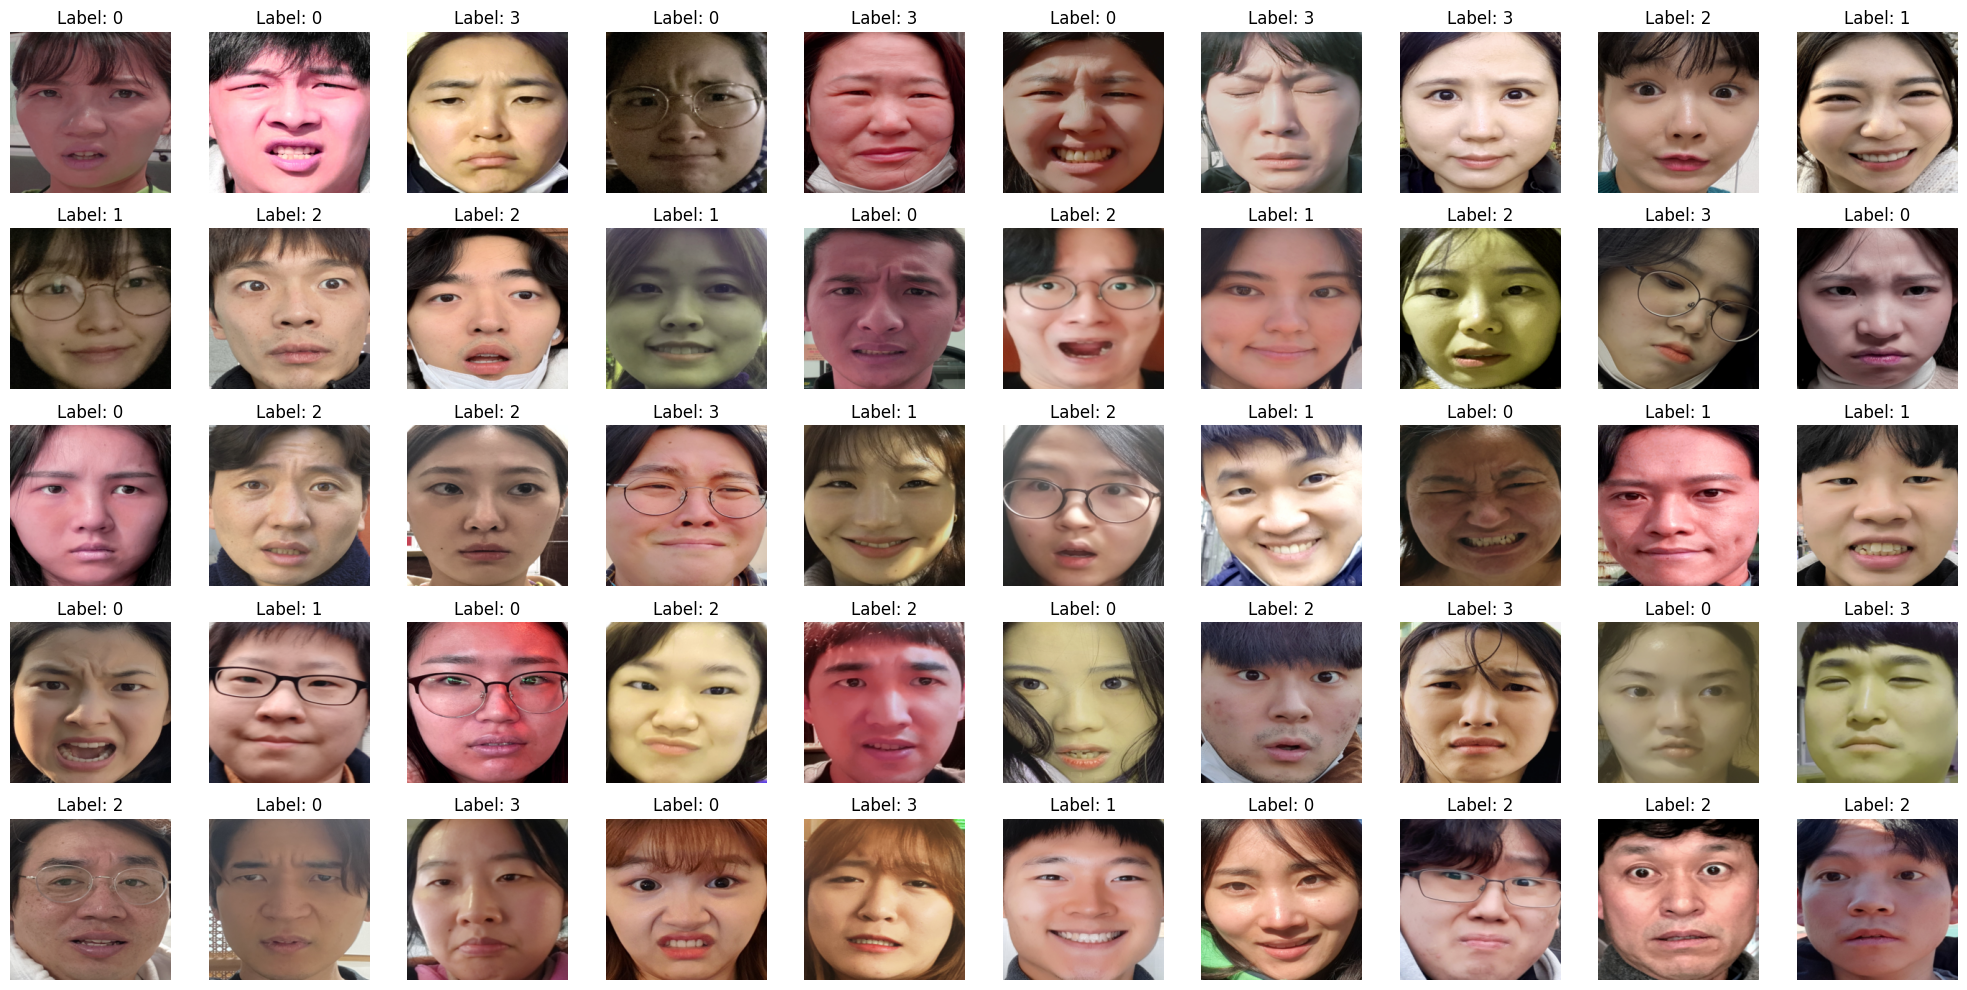

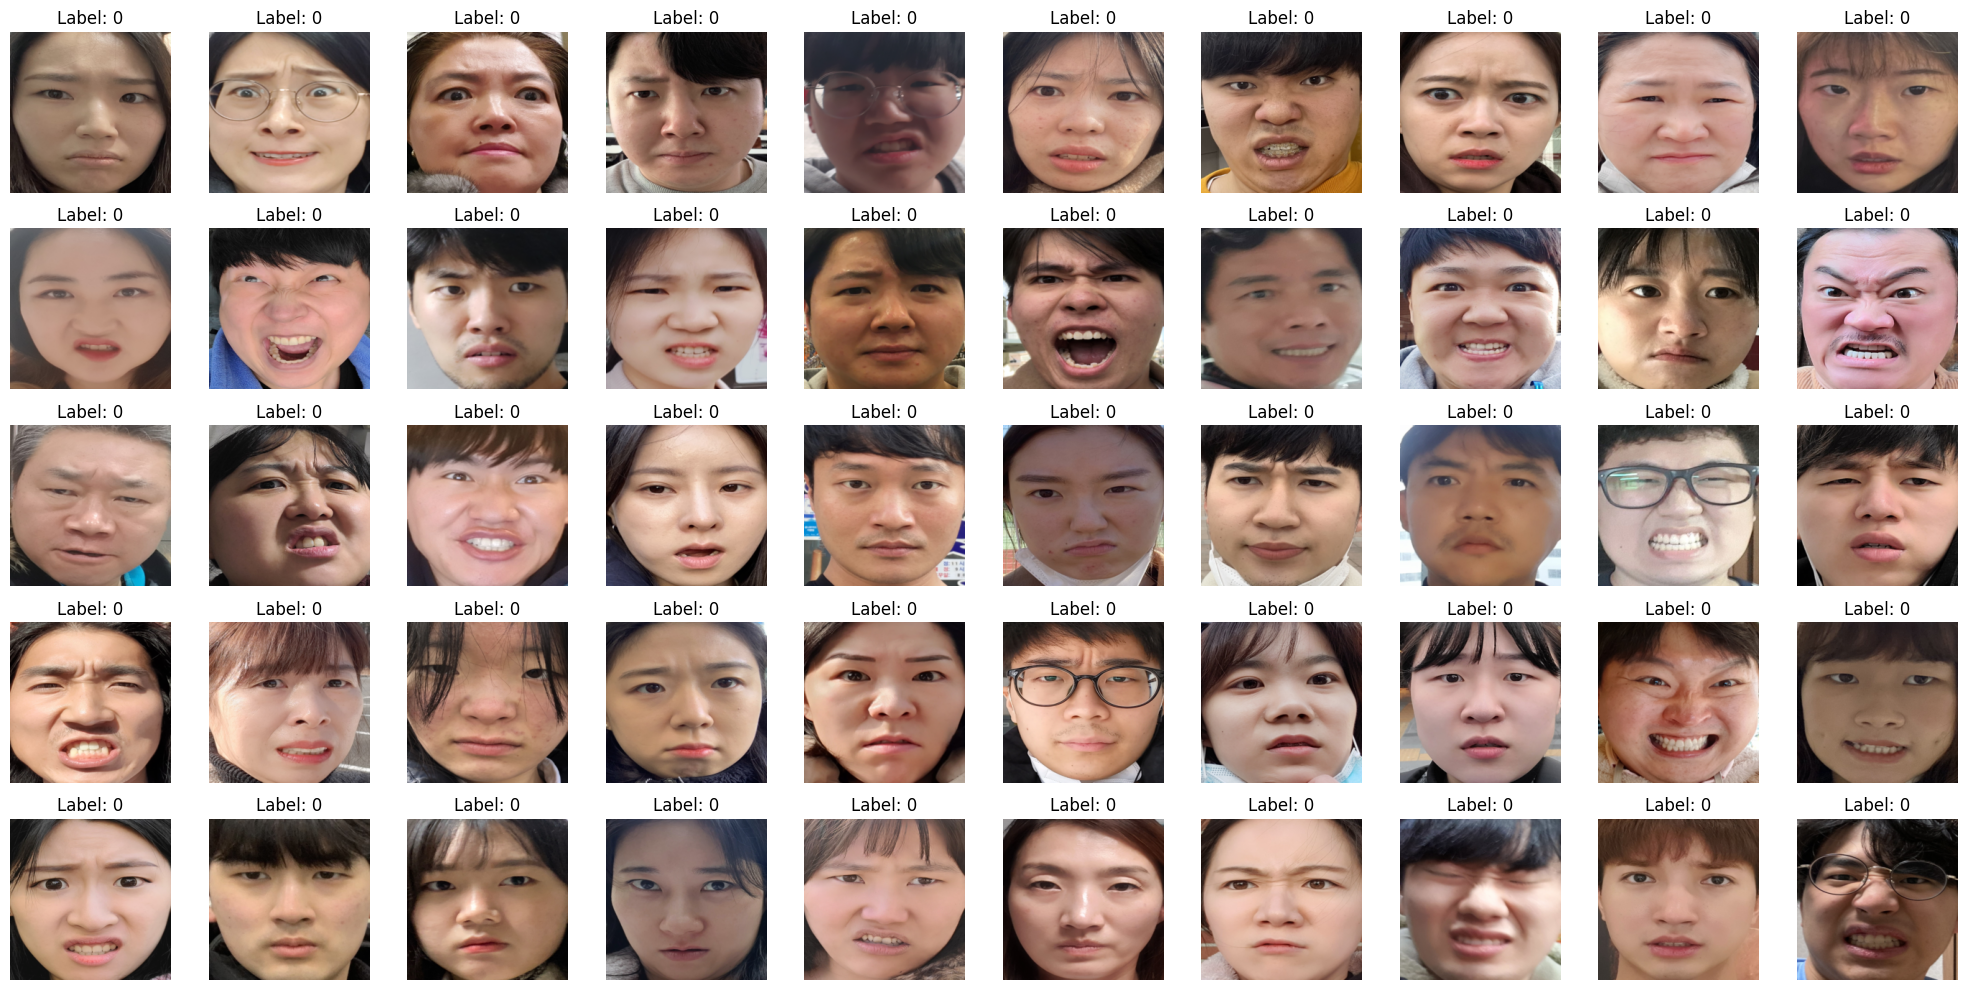

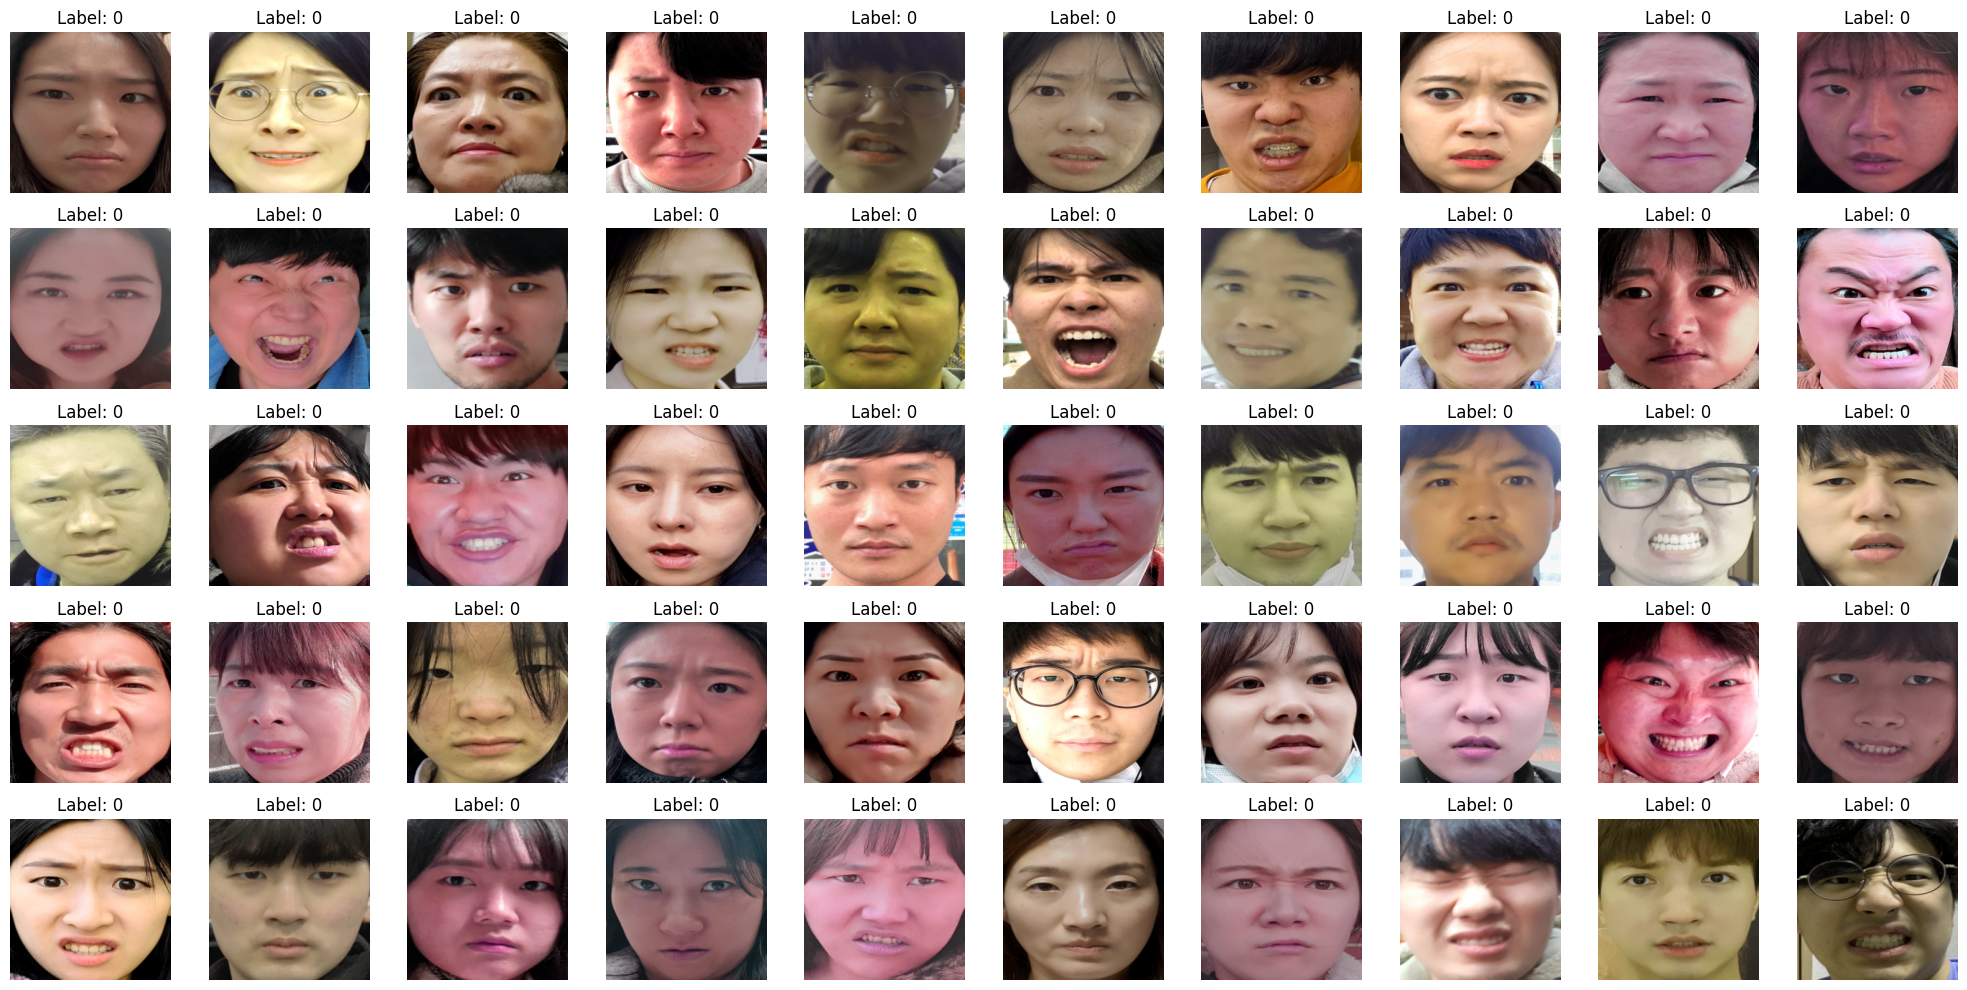

In [12]:
import matplotlib.pyplot as plt
import numpy as np

# 초기화: 빈 텐서로 시작 (이미지 크기: 3x224x224, 레이블은 스칼라)
image_dataset = torch.empty(0, 3, 224, 224)  # 0개의 이미지 텐서 (크기 3x224x224)
label_dataset = torch.empty(0, dtype=torch.long)  # 0개의 레이블 텐서 (dtype=torch.long)

# 첫 번째 배치에서 5개 이미지 시각화
for images, labels in train_dataloader:
    fig, axes = plt.subplots(5, 10, figsize=(20, 10))  # 5개 이미지를 한 줄로 출력
    for i in range(50):      
        image_dataset = torch.cat((image_dataset, images[i].unsqueeze(0)), dim=0)     
        label_dataset = torch.cat((label_dataset, labels[i].unsqueeze(0)), dim=0)   
        ax = axes[i // 10, i % 10]  # 5행 10열 배열에서 (i // 10)과 (i % 10)으로 인덱스 접근
        image = images[i].permute(1, 2, 0).numpy()  # (C, H, W) -> (H, W, C)로 변환
        image = np.clip(image * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406]), 0, 1)  # 역정규화
        ax.imshow(image)
        ax.set_title(f"Label: {labels[i].item()}")
        ax.axis('off')
    plt.tight_layout()  # 서브플롯 간 간격을 자동으로 맞춤
    plt.show()
    break  # 첫 번째 배치만 시각화

# 첫 번째 배치에서 5개 이미지 시각화
for images, labels in train_dataloader_origin:
    fig, axes = plt.subplots(5, 10, figsize=(20, 10))  # 5개 이미지를 한 줄로 출력
    for i in range(50):      
        image_dataset = torch.cat((image_dataset, images[i].unsqueeze(0)), dim=0)     
        label_dataset = torch.cat((label_dataset, labels[i].unsqueeze(0)), dim=0)   
        ax = axes[i // 10, i % 10]  # 5행 10열 배열에서 (i // 10)과 (i % 10)으로 인덱스 접근
        image = images[i].permute(1, 2, 0).numpy()  # (C, H, W) -> (H, W, C)로 변환
        image = np.clip(image * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406]), 0, 1)  # 역정규화
        ax.imshow(image)
        ax.set_title(f"Label: {labels[i].item()}")
        ax.axis('off')
    plt.tight_layout()  # 서브플롯 간 간격을 자동으로 맞춤
    plt.show()
    break  # 첫 번째 배치만 시각화

# 첫 번째 배치에서 5개 이미지 시각화
for images, labels in train_dataloader_augment:
    fig, axes = plt.subplots(5, 10, figsize=(20, 10))  # 5개 이미지를 한 줄로 출력
    for i in range(50):      
        image_dataset = torch.cat((image_dataset, images[i].unsqueeze(0)), dim=0)     
        label_dataset = torch.cat((label_dataset, labels[i].unsqueeze(0)), dim=0)   
        ax = axes[i // 10, i % 10]  # 5행 10열 배열에서 (i // 10)과 (i % 10)으로 인덱스 접근
        image = images[i].permute(1, 2, 0).numpy()  # (C, H, W) -> (H, W, C)로 변환
        image = np.clip(image * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406]), 0, 1)  # 역정규화
        ax.imshow(image)
        ax.set_title(f"Label: {labels[i].item()}")
        ax.axis('off')
    plt.tight_layout()  # 서브플롯 간 간격을 자동으로 맞춤
    plt.show()
    break  # 첫 번째 배치만 시각화


In [5]:
# ViT 모델 로드 (pretrained 모델 사용)
model = ViTForImageClassification.from_pretrained('google/vit-base-patch16-224-in21k', num_labels=4)
model.eval()

# 장치 설정 (GPU가 있으면 GPU 사용)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# 옵티마이저와 손실 함수
optimizer = optim.Adam(model.parameters(), lr=1e-5)
criterion = nn.CrossEntropyLoss()

Some weights of ViTForImageClassification were not initialized from the model checkpoint at google/vit-base-patch16-224-in21k and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [6]:
print(image_dataset.shape)
print(label_dataset.shape)

torch.Size([50, 3, 224, 224])
torch.Size([50])


In [7]:
import torch
from torch.utils.data import DataLoader, TensorDataset

# 피처맵 저장 리스트
features = {
    "input_layer": [],
    "middle_layer": [],
    "output_layer": [],
}

# Hook 함수 정의
def get_feature_map(name):
    def hook_fn(module, input, output):
        # 출력이 튜플일 경우, 텐서만 저장하도록 수정
        if isinstance(output, tuple):  # output이 튜플일 경우
            features[name] = output[0].detach()  # 첫 번째 요소가 텐서일 경우
        else:
            features[name] = output.detach()  # output이 텐서일 경우
    return hook_fn


# Hook 등록: 입력층과 가까운 레이어
input_layer = model.vit.embeddings
input_handle = input_layer.register_forward_hook(get_feature_map("input_layer"))

# Hook 등록: 중간 레이어 (예: 6번째 Transformer 블록)
middle_layer = model.vit.encoder.layer[6]  # 중간 위치
middle_handle = middle_layer.register_forward_hook(get_feature_map("middle_layer"))

# Hook 등록: 출력층과 가까운 레이어
output_layer = model.vit.encoder.layer[-1]  # 마지막 Transformer 블록
output_handle = output_layer.register_forward_hook(get_feature_map("output_layer"))

images, labels = image_dataset.to(device), label_dataset.to(device)
# 모델 실행
with torch.no_grad():
    outputs = model(images)  # 전체 이미지 처리


# Hook 제거
input_handle.remove()
middle_handle.remove()
output_handle.remove()

# 피처맵 크기 확인
print("Input Layer Feature Map:", len(features["input_layer"]), features["input_layer"][0].shape)
print("Middle Layer Feature Map:", len(features["middle_layer"]), features["middle_layer"][0].shape)
print("Output Layer Feature Map:", len(features["output_layer"]), features["output_layer"][0].shape)



Input Layer Feature Map: 50 torch.Size([197, 768])
Middle Layer Feature Map: 50 torch.Size([197, 768])
Output Layer Feature Map: 50 torch.Size([197, 768])


In [8]:
# 피처맵 크기 확인
print("Input Layer Feature Map:", len(features["input_layer"]), features["input_layer"].shape)
print("Middle Layer Feature Map:", len(features["middle_layer"]), features["middle_layer"][0].shape)
print("Output Layer Feature Map:", len(features["output_layer"]), features["output_layer"][0].shape)

Input Layer Feature Map: 50 torch.Size([50, 197, 768])
Middle Layer Feature Map: 50 torch.Size([197, 768])
Output Layer Feature Map: 50 torch.Size([197, 768])


In [9]:
print(label_dataset.shape)

torch.Size([50])


In [10]:
input_features = torch.cat([f.flatten(start_dim=1) for f in features["input_layer"]], dim=0)
print("Input Features shape:", input_features.shape)

Input Features shape: torch.Size([9850, 768])


In [11]:
# Hook 결과는 리스트가 아닌 단일 텐서로 저장됨
input_features = features["input_layer"].flatten(start_dim=1)  # torch.Size([10, 197 * 768])
middle_features = features["middle_layer"].flatten(start_dim=1)  # torch.Size([10, 197 * 768])
output_features = features["output_layer"].flatten(start_dim=1)  # torch.Size([10, 197 * 768])
# 출력 형태 확인
print("Input Features shape:", input_features.shape)
print("Middle Features shape:", middle_features.shape)
print("Output Features shape:", output_features.shape)

# 학습용/테스트용 데이터셋 분리
train_size = int(0.8 * input_features.size(0))
test_size = input_features.size(0) - train_size

input_train_features = input_features[:train_size]
input_test_features = input_features[train_size:]
middle_train_features = middle_features[:train_size]
middle_test_features = middle_features[train_size:]
output_train_features = output_features[:train_size]
output_test_features = output_features[train_size:]
train_labels = labels[:train_size]
test_labels = labels[train_size:]

# TensorDataset 및 DataLoader 생성
def create_dataloader(features, labels):
    dataset = TensorDataset(features, labels)
    return DataLoader(dataset, batch_size=32, shuffle=True)

input_train_loader = create_dataloader(input_train_features, train_labels)
input_test_loader = create_dataloader(input_test_features, test_labels)

middle_train_loader = create_dataloader(middle_train_features, train_labels)
middle_test_loader = create_dataloader(middle_test_features, test_labels)

output_train_loader = create_dataloader(output_train_features, train_labels)
output_test_loader = create_dataloader(output_test_features, test_labels)



Input Features shape: torch.Size([50, 151296])
Middle Features shape: torch.Size([50, 151296])
Output Features shape: torch.Size([50, 151296])


In [12]:
print("Image device:", images.device)
print("Labels device:", labels.device)
print("Input Layer Features device:", train_labels.device)
print("Model device:", next(model.parameters()).device)


Image device: cuda:0
Labels device: cuda:0
Input Layer Features device: cuda:0
Model device: cuda:0


In [19]:
from torch import nn

# 간단한 분류기 정의
classifier = nn.Linear(input_features.size(1), 4)  # 감정 분류 4개 클래스
classifier.to(device)

# Loss와 Optimizer 설정
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(classifier.parameters(), lr=0.001)

# 학습 함수 정의
def train(classifier, train_loader, num_epochs=3):
    classifier.train()  # 모델을 학습 모드로 설정
    
    for epoch in range(num_epochs):  # 에포크 루프
        running_loss = 0.0
        correct = 0
        total = 0
        
        # 배치마다 학습 진행
        for batch in train_loader:
            features, labels = batch
            features = features.to(device)
            labels = labels.to(device)
            
            optimizer.zero_grad()  # 기울기 초기화
            outputs = classifier(features)  # 분류기 예측
            loss = criterion(outputs, labels)  # 손실 계산
            loss.backward()  # 역전파
            optimizer.step()  # 가중치 업데이트
            
            # 손실과 정확도 계산
            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)  # 예측값
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
        
        # 에포크별 손실과 정확도 출력
        epoch_loss = running_loss / len(train_loader)
        epoch_accuracy = 100 * correct / total
        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss:.4f}, Accuracy: {epoch_accuracy:.2f}%")


# 평가 함수 정의
def evaluate(classifier, test_loader):
    classifier.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for batch in test_loader:
            features, labels = batch
            features = features.to(device)
            labels = labels.to(device)
            
            outputs = classifier(features)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    accuracy = correct / total
    return accuracy

acc_list = []

# input, middle, output 피처별 성능 비교
for feature_loader, feature_test_loader, feature_name in zip(
    [input_train_loader, middle_train_loader, output_train_loader],  # train loaders
    [input_test_loader, middle_test_loader, output_test_loader],  # test loaders
    ["Input Layer", "Middle Layer", "Output Layer"]
):
    print(f"Training {feature_name} classifier")
    train(classifier, feature_loader, num_epochs=10)
    accuracy = evaluate(classifier, feature_test_loader)  # 각 레이어에 맞는 테스트 로더 사용
    acc_list.append((feature_name, accuracy))
    print(f"{feature_name} classifier accuracy: {accuracy:.4f}")


Training Input Layer classifier
Epoch [1/10], Loss: 14.2358, Accuracy: 25.00%
Epoch [2/10], Loss: 4.8139, Accuracy: 57.50%
Epoch [3/10], Loss: 1.3805, Accuracy: 87.50%
Epoch [4/10], Loss: 0.9429, Accuracy: 92.50%
Epoch [5/10], Loss: 0.0231, Accuracy: 97.50%
Epoch [6/10], Loss: 0.0000, Accuracy: 100.00%
Epoch [7/10], Loss: 0.0000, Accuracy: 100.00%
Epoch [8/10], Loss: 0.0000, Accuracy: 100.00%
Epoch [9/10], Loss: 0.0000, Accuracy: 100.00%
Epoch [10/10], Loss: 0.0000, Accuracy: 100.00%
Input Layer classifier accuracy: 0.1000
Training Middle Layer classifier
Epoch [1/10], Loss: 30.8967, Accuracy: 22.50%
Epoch [2/10], Loss: 42.5909, Accuracy: 77.50%
Epoch [3/10], Loss: 16.2727, Accuracy: 85.00%
Epoch [4/10], Loss: 0.9785, Accuracy: 97.50%
Epoch [5/10], Loss: 0.0000, Accuracy: 100.00%
Epoch [6/10], Loss: 0.0000, Accuracy: 100.00%
Epoch [7/10], Loss: 0.0000, Accuracy: 100.00%
Epoch [8/10], Loss: 3.5300, Accuracy: 95.00%
Epoch [9/10], Loss: 3.0871, Accuracy: 97.50%
Epoch [10/10], Loss: 0.0000

Epoch [6/10], Loss: 1.5475, Accuracy: 95.00%
Epoch [7/10], Loss: 0.0656, Accuracy: 97.50%
Epoch [8/10], Loss: 0.0000, Accuracy: 100.00%
Epoch [9/10], Loss: 1.2628, Accuracy: 95.00%
Epoch [10/10], Loss: 0.0000, Accuracy: 100.00%
Output Layer classifier accuracy: 0.4000


In [21]:
for name, acc in acc_list:
  print(f"{name} Acc : {acc:.4f}")

Input Layer Acc : 0.1000
Middle Layer Acc : 0.2000
Output Layer Acc : 0.4000
